In [18]:
from datetime import datetime
from pprint import pprint

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from mplsoccer import Pitch
import numpy as np
from PIL import Image
import polars as pl
from scipy import stats
from scipy.ndimage import gaussian_filter
import shap
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import xgboost as xgb

## Match data

In [2]:
match_df = pl.read_parquet('Skillcorner data/RealMadrid/matches.parquet')
# Data is only available for "closed" matches
match_df = match_df.filter(pl.col('status') == 'closed')
match_ids = match_df['id'].to_list()
# match_ids = match_df.filter(pl.col('competition_edition_id').is_in([900, 546]))['id'].to_list()
print('Num of matches:', len(match_ids))

Num of matches: 98


## Calculate derived metrics

In [19]:
REAL_MADRID_TEAM_ID = 262

# Derived data storage
data = {
  'match_id': [],
  'rma_shots': [],
  'rma_goals': [],
  'def_median': [],
  'mid_median': [],
  'att_median': [],
  'def_compact': [],
  'mid_compact': [],
  'att_compact': [],
  'horiz_compact': [],
  'vert_compact': [],
  'num_pressures': [],
  'home_team': [],
  'away_team': [],
  'rma_opponent': [],
  'num_shots_behind_def_line': [],
  'num_goals_behind_def_line': [],
  'min_horiz_avg': [],
  'num_shots_behind_horiz': [],
}

heatmap_data = {}

for match_id in match_ids:
  # Load meta data for match
  meta_df = pl.read_json(f'Skillcorner data/RealMadrid/meta/{match_id}.json')
  meta_players_df = meta_df.select('players').explode('players').unnest('players')
  meta_players_df = (
    meta_players_df.with_columns(
      pl.col('player_role').name.prefix_fields('player_role_')
    ).unnest('player_role')
  ).rename({'id': 'player_id', 'short_name': 'player_short_name'})
  rma_non_gk_player_ids = meta_players_df.filter(
    pl.col('team_id') == REAL_MADRID_TEAM_ID,
    pl.col('player_role_acronym') != 'GK')['player_id'].to_list()
  oppo_non_gk_player_ids = meta_players_df.filter(
    pl.col('team_id') != REAL_MADRID_TEAM_ID,
    pl.col('player_role_acronym') != 'GK')['player_id'].to_list()

  # Transform data so that Real Madrid is alway left to right
  # First determine which half to transform coordinates
  is_rma_home = (meta_df['home_team'].struct.field('id') == REAL_MADRID_TEAM_ID).item()
  home_l2r_half = meta_df['home_team_side'].item().to_list().index('right_to_left') + 1
  if is_rma_home:
    period_to_swap = home_l2r_half
  else:
    period_to_swap = 3 - home_l2r_half

  home_team = meta_df['home_team'].struct.field('short_name').item()
  away_team = meta_df['away_team'].struct.field('short_name').item()
  if is_rma_home:
    rma_opponent = away_team
  else:
    rma_opponent = home_team

  # Load tracking data for match
  track_df = pl.read_json(f'Skillcorner data/RealMadrid/tracking/{match_id}.json', infer_schema_length=10_000)
  # Only get rows that have valid timestamps and players
  track_frames_df = track_df.filter(pl.col('timestamp').is_not_null(), pl.col('player_data').list.len() != 0)
  ball_coords_df = track_frames_df.select(
    pl.col('frame'),
    pl.col('period'),
    pl.col('ball_data').struct.field('x'),
    pl.col('ball_data').struct.field('y'),
  )
  track_players_df = (                                                                                                               
      track_frames_df.select(['frame', 'timestamp', 'period', 'player_data'])                                                                         
      .explode('player_data')                                                                                                        
      .unnest('player_data')
  )
  # SkillCorner coordinate origin is located at the pitch center point
  # so to transform left-to-right and vice versa, multiply the coordinates
  # by -1. Here all RMA coordinates are transformed to left-to-right and
  # all opponent coordinates are transformed to right-to-left.
  track_players_df = track_players_df.with_columns(
    pl.when(pl.col('period') == period_to_swap)
    .then(pl.col('x', 'y') * -1)
    .otherwise(pl.col('x', 'y'))
  )
  ball_coords_df = ball_coords_df.with_columns(
    pl.when(pl.col('period') == period_to_swap)
    .then(pl.col('x') * -1)
    .otherwise(pl.col('x'))
  )
  # With all coordinates transformed for left to right for Real Madrid,
  # we can filter frames when the ball is in each third of the pitch.
  # +--------------------------------+--------------------------------+
  # |                     !          |          !                     |
  # |----+                !          |          !                +----|
  # |    |                !          |          !                |    |
  # |  RMA defensive 3rd  !     RMA mid 3rd     !  RMA attacking 3rd  |
  # |   -52.5 to -17.5    !    -17.5 to 17.5    !    17.5 to 52.5     |
  # |         35m         !         35m         !         35m         |
  # |    |                !          |          !                |    |
  # |----+                !          |          !                +----|
  # |                     !          |          !                     |
  # +--------------------------------+--------------------------------+
  def_third_frames = ball_coords_df.filter(pl.col('x') < -17.5)['frame'].to_list()
  mid_third_frames = ball_coords_df.filter(pl.col('x').is_between(-17.5, 17.5))['frame'].to_list()
  att_third_frames = ball_coords_df.filter(pl.col('x') > 17.5)['frame'].to_list()

  # Load dynamic events for match
  try:
    dynam_df = pl.read_parquet(f'Skillcorner data/RealMadrid/dynamic/{match_id}.parquet')
  except FileNotFoundError:
    print(f'Missing dynamic data for match id {match_id}!')
    continue
  # RMA shots for this match
  rma_shots_df = dynam_df.filter(
    pl.col('team_id') == REAL_MADRID_TEAM_ID,
    pl.col('end_type') == 'shot',
  )
  num_rma_shots = rma_shots_df.shape[0]
  # RMA goals for this match
  rma_goals_df = dynam_df.filter(
    pl.col('team_id') == REAL_MADRID_TEAM_ID,
    pl.col('game_interruption_after') == 'goal_for'
  )
  num_rma_goals = rma_goals_df.shape[0]

  # Tracking data for each team
  rma_track_df = track_players_df.filter(pl.col('player_id').is_in(rma_non_gk_player_ids))
  oppo_track_df = track_players_df.filter(pl.col('player_id').is_in(oppo_non_gk_player_ids))

  # To get all the opponent's defensive frames we filter when the ball is in RMA's attacking 3rd
  oppo_def_frames_df = oppo_track_df.filter(pl.col('frame').is_in(att_third_frames))
  oppo_mid_frames_df = oppo_track_df.filter(pl.col('frame').is_in(mid_third_frames))
  # Likewise, for the opponent's attacking frames we filter when the ball is in RMA's defensive 3rd
  oppo_att_frames_df = oppo_track_df.filter(pl.col('frame').is_in(def_third_frames))

  # Here we get the median value of the opponent defender closest to the opponent's goal (highest x value) over the match
  def_median = oppo_def_frames_df.group_by('frame').agg(pl.col('x').top_k(3).mean())['x'].median()
  mid_median = oppo_mid_frames_df.group_by('frame').agg(pl.col('x').top_k(3).mean())['x'].median()
  # This gets the median of the highest meter the opponent's defense gets when attacking RMA
  att_median = oppo_att_frames_df.group_by('frame').agg(pl.col('x').top_k(3).mean())['x'].median()

  # Calculate the average compactness of the defense by getting the mean squared distance
  # from the centroid of all players
  avg_def_compactness = oppo_def_frames_df.with_columns(
    pl.col('x').mean().over('frame').alias('centroid_x'),
    pl.col('y').mean().over('frame').alias('centroid_y'),
  ).with_columns(
    (
      (pl.col('x') - pl.col('centroid_x')).pow(2) +
      (pl.col('y') - pl.col('centroid_y')).pow(2)
    ).sqrt().alias('dist_from_centroid'),
  ).group_by('frame').agg(
    pl.col('dist_from_centroid').mean().alias('compactness')
  )['compactness'].mean()

  # Measure the horizontal compactness by getting the difference between the
  # min and max pitch location of the furthest back 8 defensive players
  oppo_compact_df = oppo_def_frames_df.select(
    pl.col('frame'),
    pl.col('x').top_k(8).max().over('frame').alias('max_horiz'),
    pl.col('x').top_k(8).min().over('frame').alias('min_horiz'),
  ).select(
    pl.col('max_horiz'),
    pl.col('min_horiz'),
    (pl.col('max_horiz') - pl.col('min_horiz')).alias('horiz_diff'),
  )
  avg_horiz_compactness = oppo_compact_df['horiz_diff'].mean()

  # Measure the vertical compactness by gett the difference between the
  # min and max pitch location of the furthest back 8 defensive players
  avg_vert_compactness = oppo_def_frames_df.select(
    pl.col('frame'),
    pl.col('y').top_k(8).max().over('frame').alias('max_vert'),
    pl.col('y').top_k(8).min().over('frame').alias('min_vert'),
  ).select(
    (pl.col('max_vert') - pl.col('min_vert')).alias('vert_diff'),
  )['vert_diff'].mean()

  # The number of pressures by defensive players
  pressures_on_rma = dynam_df.filter(
    pl.col('frame_start').is_in(att_third_frames) | pl.col('frame_end').is_in(att_third_frames)
  ).filter(
    pl.col('event_subtype') == 'pressure',
    pl.col('team_id') != REAL_MADRID_TEAM_ID,
  )
  num_pressures = pressures_on_rma.shape[0]

  # The number of shots behind the derived median defensive line height
  shots_behind_def_line_df = dynam_df.filter(
    pl.col('team_id') == REAL_MADRID_TEAM_ID,
    pl.col('end_type') == 'shot',
    pl.col('x_end') > def_median
  )
  num_shots_behind_def_line = shots_behind_def_line_df.shape[0]

  # The number of goals behind the derived median defensive line height
  goals_behind_def_line_df = dynam_df.filter(
    pl.col('team_id') == REAL_MADRID_TEAM_ID,
    pl.col('game_interruption_after') == 'goal_for',
    pl.col('x_end') > def_median,
  )
  num_goals_behind_def_line = goals_behind_def_line_df.shape[0]

  # The number of shots behind the minimum horizontal compactness
  min_horiz_avg = oppo_compact_df['min_horiz'].mean()
  shots_behind_horiz_df = dynam_df.filter(
    pl.col('team_id') == REAL_MADRID_TEAM_ID,
    pl.col('end_type') == 'shot',
    pl.col('x_end') > min_horiz_avg,
  )
  num_shots_behind_hoirz = shots_behind_horiz_df.shape[0]

  # Heatmap data
  oppo_def_coords_df = track_players_df.filter(
    pl.col('frame').is_in(att_third_frames),
    pl.col('player_id').is_in(oppo_non_gk_player_ids)
  )
  heatmap_data[match_id] = {}
  heatmap_data[match_id]['def_coords'] = oppo_def_coords_df
  heatmap_data[match_id]['line_height'] = def_median
  heatmap_data[match_id]['rma_shots'] = rma_shots_df.select(pl.col('x_end'), pl.col('y_end')).to_numpy()
  heatmap_data[match_id]['rma_goals'] = rma_goals_df.select(pl.col('x_end'), pl.col('y_end')).to_numpy()
  heatmap_data[match_id]['pressures'] = pressures_on_rma
  heatmap_data[match_id]['horiz_compact'] = oppo_compact_df.select(
    pl.col('max_horiz'), pl.col('min_horiz'), pl.col('horiz_diff')
  )
  heatmap_data[match_id]['home_team'] = home_team
  heatmap_data[match_id]['away_team'] = away_team
  heatmap_data[match_id]['home_team_score'] = meta_df['home_team_score'].item()
  heatmap_data[match_id]['away_team_score'] = meta_df['away_team_score'].item()
  heatmap_data[match_id]['date'] = datetime.strptime(meta_df['date_time'].item()[:10], '%Y-%m-%d').strftime('%B %d, %Y')

  # Populate data
  data['match_id'].append(match_id)
  data['rma_shots'].append(num_rma_shots)
  data['rma_goals'].append(num_rma_goals)
  data['def_median'].append(def_median)
  data['mid_median'].append(mid_median)
  data['att_median'].append(att_median)
  data['def_compact'].append(avg_def_compactness)
  data['horiz_compact'].append(avg_horiz_compactness)
  data['vert_compact'].append(avg_vert_compactness)
  data['num_pressures'].append(num_pressures)
  data['num_shots_behind_def_line'].append(num_shots_behind_def_line)
  data['num_goals_behind_def_line'].append(num_goals_behind_def_line)
  data['min_horiz_avg'].append(min_horiz_avg)
  data['num_shots_behind_horiz'].append(num_shots_behind_hoirz)
  data['home_team'].append(home_team)
  data['away_team'].append(away_team)
  data['rma_opponent'].append(rma_opponent)

print('Num data points:', len(data['match_id']))


Missing dynamic data for match id 1274919!
Num data points: 97


## Load xG

In [20]:
# Load xG output from project3_xg.ipynb notebook
rma_xg = pl.read_parquet('rma_xg.parquet')
oppo_xg = pl.read_parquet('oppo_xg.parquet')

# Convert data dictionary to a data frame
actual_data = {k: v for k, v in data.items() if v}
data_df = pl.DataFrame(actual_data)

data_df = data_df.join(rma_xg, on='match_id', how='left').rename({'xG': 'rma_xG'})
data_df = data_df.join(oppo_xg, on='match_id', how='left').rename({'xG': 'oppo_xG'})
data_df.shape

(97, 19)

In [21]:
# Mapping of dataset name to logo filename
logo_lookup = {
  'Alavés': 'alaves',
  'Arsenal': 'arsenal',
  'Atalanta': 'atalanta',
  'Athletic Bilbao': 'athletic-club',
  'Atlético Madrid': 'atletico-madrid',
  'Bayern Munchen': 'bayern-münchen',
  'Betis Balompié': 'betis-balompie',
  'CA Osasuna': 'osasuna',
  'CF Cadiz': 'cadiz',
  'Celta Vigo': 'celta',
  'Dortmund': 'dortmund',
  'FC Barcelona': 'barcelona',
  'FC Union Berlin': 'union-berlin',
  'Getafe CF': 'getafe',
  'Girona': 'girona',
  'Granada CF': 'granada',
  'LOSC Lille': 'losc-lille',
  'Leganés': 'leganes',
  'Leipzig': 'leipzig',
  'Liverpool': 'liverpool',
  'Manchester City': 'manchester-city',
  'Milan': 'milan',
  'Napoli': 'napoli',
  'RCD Espanyol': 'espanyol',
  'RCD Mallorca': 'mallorca',
  'Rayo Vallecano': 'rayo-vallecano',
  'Real Sociedad': 'real-sociedad',
  'Real Valladolid': 'real-valladolid',
  'SC Braga': 'sc-braga',
  'Salzbourg': 'salzbourg',
  'Sevilla FC': 'sevilla',
  'Stade Brestois': 'stade-brestois',
  'Stuttgart': 'stuttgart',
  'UD Almería': 'almeria',
  'UD Las Palmas': 'las-palmas',
  'Valencia CF': 'valencia',
  'Villarreal CF': 'villarreal',
}

In [6]:
# Use a TTF font file for Matplotlib plot text
font_path = 'fonts/Roboto/static/Roboto-Medium.ttf'
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = prop.get_name()

# Plot colors
BG_COLOR = '#1e1e1e'
TEXT_COLOR = '#ffffff'
DOT_COLOR = 'lightgreen'
SLOPE_COLOR = '#00F5FF'
CI_COLOR = '#00E5FF'

## Plot drawing code

In [ ]:
def draw_plot(x, y, title, x_label, y_label, point_sizes=None, match_ids=None, show_grid=False, show_legend=True, opponents=None):
  fig, ax = plt.subplots(figsize=(10, 5))
  fig.set_facecolor(BG_COLOR)
  ax.set_facecolor(BG_COLOR)
  ax.set_xlabel(TEXT_COLOR)
  ax.set_ylabel(TEXT_COLOR)
  for spine in ax.spines.values():
    spine.set_color(TEXT_COLOR)
  ax.tick_params(axis='x', colors=TEXT_COLOR)
  ax.tick_params(axis='y', colors=TEXT_COLOR)

  # sizes = point_sizes if point_sizes else 25
  # plt.scatter(x, y, s=sizes, c=DOT_COLOR, label='Individual Match')
  if point_sizes:
    plt.scatter(x, y, s=point_sizes, c=DOT_COLOR)
  else:
    plt.scatter(x, y, s=25, c=DOT_COLOR, label='Individual Match')

  goals_handles = None
  if point_sizes:
    uniq = sorted(set(point_sizes))
    leg_vals = []
    leg_lbls = []
    for i, s in enumerate(uniq):
      leg_vals.append(s)
      leg_lbls.append(f'{i} Goals')

    goals_handles = [
      Line2D([0], [0],
          marker='o',
          color='w',
          label=lbl,
          markerfacecolor=DOT_COLOR,
          markersize=np.sqrt(sz)+3,
          markeredgecolor='None',
          linestyle='None')
      for sz, lbl in zip(leg_vals, leg_lbls)
    ]

  # If opponent names are provided, add logos to the scatter plot points
  if opponents:
    for i, opponent in enumerate(opponents):
      fname = logo_lookup.get(opponent, None)
      if fname:
        try:
          logo = Image.open(f'logos/la-liga/{fname}.football-logos.cc.png').convert("RGBA")
        except:
          continue  # Skip if logo is not found or cannot be opened
        img_box = OffsetImage(logo, zoom=0.3)
        ab = AnnotationBbox(img_box, (x[i], y[i]), frameon=False, pad=0.0)
        ax.add_artist(ab)

  # Label points with match ids if provided
  if match_ids:
    for xi, yi, mid in zip(x, y, match_ids):
      plt.annotate(str(mid), (xi, yi), textcoords="offset points", xytext=(5,5), ha='left', fontsize=9, color=TEXT_COLOR)

  # Regression line
  coeffs = np.polyfit(x, y, 1)
  slope, intercept = coeffs
  x_line = np.linspace(x.min(), x.max(), 200)
  y_line = slope * x_line + intercept

  # Calculate standard error and confidence interval
  n = len(x)
  residuals = y - (slope * x + intercept)
  std_error = np.sqrt(np.sum(residuals**2) / (n - 2))
  x_mean = np.mean(x)
  sxx = np.sum((x - x_mean)**2)
  # 95% confidence interval
  t_val = stats.t.ppf(0.975, n - 2)
  margin = t_val * std_error * np.sqrt(1/n + (x_line - x_mean)**2 / sxx)
  uncertain_bound = t_val * (std_error / np.sqrt(sxx))

  plt.plot(x_line, y_line, color=SLOPE_COLOR, linestyle='--', linewidth=1, label=f'Slope: {slope:.2f} ± {uncertain_bound:.2f}')
  plt.fill_between(x_line, y_line - margin, y_line + margin, alpha=0.2, color=CI_COLOR)

  plt.title(title, color='white', size=18)
  plt.xlabel(x_label, color='white')
  plt.ylabel(y_label, color='white')
  if show_grid:
    plt.grid(True)
  current_handles, _ = plt.gca().get_legend_handles_labels()
  if goals_handles:
    all_handles = current_handles + goals_handles
  else:
    all_handles = current_handles
  plt.legend(
    handles=all_handles,
    facecolor=BG_COLOR,
    edgecolor=TEXT_COLOR,
    labelcolor=TEXT_COLOR,
  )
  plt.show()

In [8]:
def plot_line_height(x, y, title, x_label, y_label, point_colors=None, point_sizes=None, match_ids=None, opponents=None):
  fig, ax = plt.subplots(figsize=(10, 5))
  fig.set_facecolor(BG_COLOR)
  ax.set_facecolor(BG_COLOR)
  ax.set_xlabel(TEXT_COLOR)
  ax.set_ylabel(TEXT_COLOR)
  # ax.spines['bottom'].set_color(TEXT_COLOR)
  for spine in ax.spines.values():
    spine.set_color(TEXT_COLOR)
  ax.tick_params(axis='x', colors=TEXT_COLOR)
  ax.tick_params(axis='y', colors=TEXT_COLOR)

  # sizes = point_sizes if point_sizes else 25
  if point_sizes:
    plt.scatter(x, y, s=point_sizes, c=DOT_COLOR)
  else:
    plt.scatter(x, y, s=25, c=DOT_COLOR, label='Individual Match')

  goals_handles = None
  if point_sizes:
    uniq = sorted(set(point_sizes))
    leg_vals = []
    leg_lbls = []
    for i, s in enumerate(uniq):
      leg_vals.append(s)
      leg_lbls.append(f'{i} Goals')

    goals_handles = [
      Line2D([0], [0],
          marker='o',
          color='w',
          label=lbl,
          markerfacecolor=DOT_COLOR,
          markersize=np.sqrt(sz)+3,
          markeredgecolor='None',
          linestyle='None')
      for sz, lbl in zip(leg_vals, leg_lbls)
    ]

  # If opponent names are provided, add logos to the scatter plot points
  if opponents:
    for i, opponent in enumerate(opponents):
      fname = logo_lookup.get(opponent, None)
      if fname:
        try:
          logo = Image.open(f'logos/la-liga/{fname}.football-logos.cc.png').convert("RGBA")
        except:
          continue  # Skip if logo is not found or cannot be opened
        img_box = OffsetImage(logo, zoom=0.3)
        ab = AnnotationBbox(img_box, (x[i], y[i]), frameon=False, pad=0.0)
        ax.add_artist(ab)

  # Label points with match ids
  if match_ids:
    for xi, yi, mid in zip(x, y, match_ids):
      plt.annotate(str(mid), (xi, yi), textcoords="offset points", xytext=(5,5), ha='left', fontsize=9, color=TEXT_COLOR)

  # Regression line
  coeffs = np.polyfit(x, y, 1)
  slope, intercept = coeffs
  x_line = np.linspace(x.min(), x.max(), 200)
  y_line = slope * x_line + intercept

  # Calculate standard error and confidence interval
  n = len(x)
  residuals = y - (slope * x + intercept)
  # convert Polars Series to a numpy array to avoid numpy calling Series.sum(axis=...)
  # residuals = residuals.to_numpy()
  std_error = np.sqrt(np.sum(residuals**2) / (n - 2))
  x_mean = np.mean(x)
  sxx = np.sum((x - x_mean)**2)
  # 95% confidence interval
  t_val = stats.t.ppf(0.975, n - 2)
  margin = t_val * std_error * np.sqrt(1/n + (x_line - x_mean)**2 / sxx)
  uncertain_bound = t_val * (std_error / np.sqrt(sxx))

  plt.plot(x_line, y_line, color=SLOPE_COLOR, linestyle='--', linewidth=1, label=f'Slope: {slope:.2f} ± {uncertain_bound:.2f}')
  plt.fill_between(x_line, y_line - margin, y_line + margin, alpha=0.2, color=CI_COLOR)

  # Relabel x ticks in terms of distance from goal
  x_positions, x_labels = plt.xticks()
  x_lim = plt.xlim()
  new_labels = []
  for x in x_labels:
    new_labels.append(52.5 - x.get_position()[0])
  plt.xticks(x_positions, new_labels)
  plt.xlim(x_lim)
  # Since the x-axis values inverted (decreasing from left to right),
  # the x-axis should also invert to show increasing distance from goal from left to right
  plt.gca().invert_xaxis()

  plt.title(title, color=TEXT_COLOR, size=18)
  plt.xlabel(x_label, color=TEXT_COLOR)
  plt.ylabel(y_label, color=TEXT_COLOR)

  current_handles, _ = plt.gca().get_legend_handles_labels()
  if goals_handles:
    all_handles = current_handles + goals_handles
  else:
    all_handles = current_handles
  plt.legend(
    handles=all_handles,
    facecolor=BG_COLOR,
    edgecolor=TEXT_COLOR,
    labelcolor=TEXT_COLOR,
  )
  # plt.grid(True)
  plt.show()

## Defensive line height plots

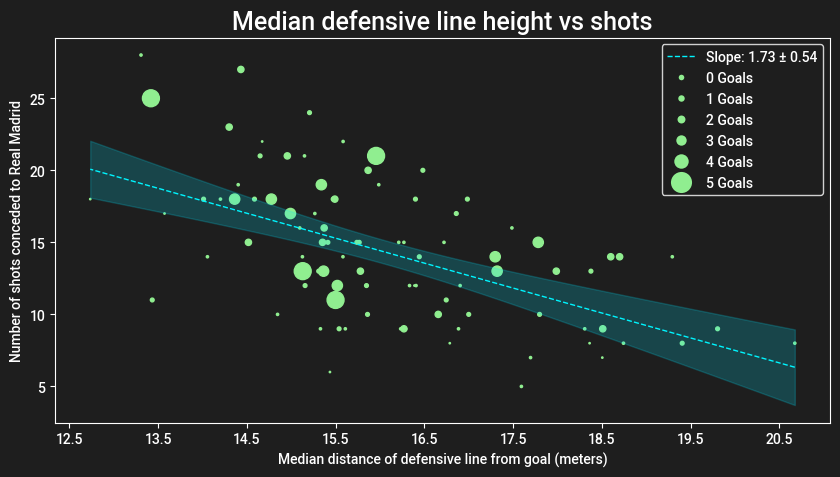

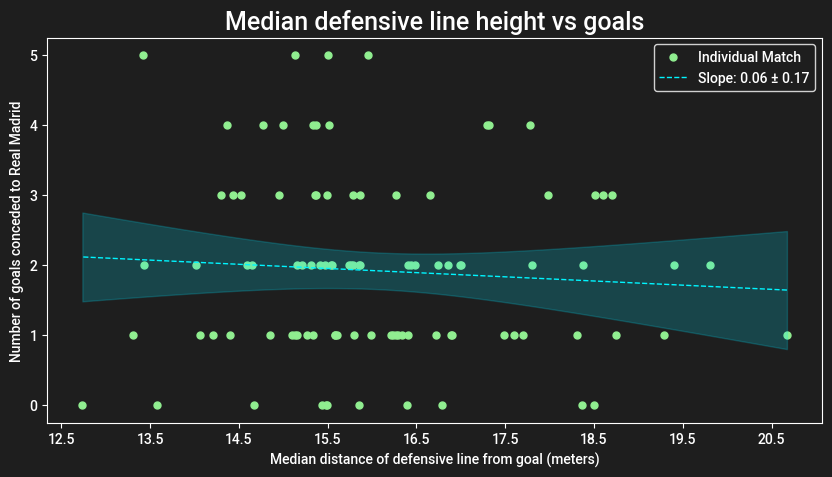

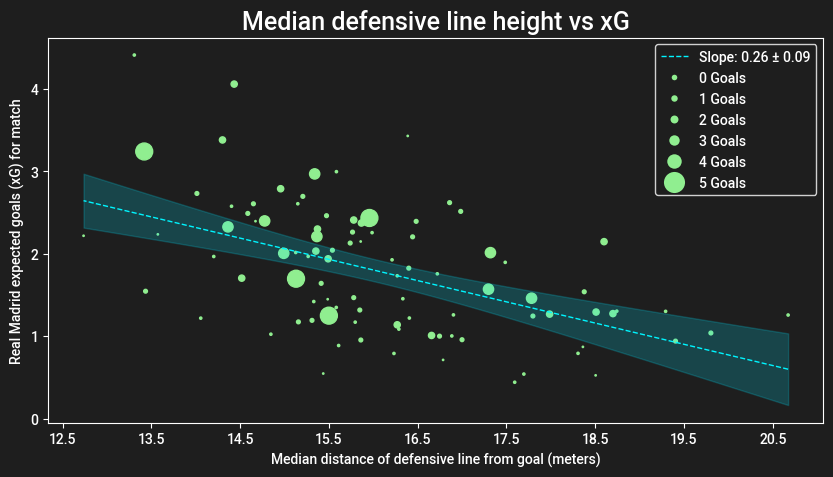

In [9]:
plot_line_height(
  data_df['def_median'].to_numpy(),
  data_df['rma_shots'].to_numpy(),
  title='Median defensive line height vs shots',
  x_label='Median distance of defensive line from goal (meters)',
  y_label='Number of shots conceded to Real Madrid',
  point_sizes=(data_df['rma_goals'].exp()).to_list(),
  # match_ids=data_df['match_id'].to_list(),
)

plot_line_height(
  data_df['def_median'].to_numpy(),
  data_df['rma_goals'].to_numpy(),
  title='Median defensive line height vs goals',
  x_label='Median distance of defensive line from goal (meters)',
  y_label='Number of goals conceded to Real Madrid',
)

plot_line_height(
  data_df['def_median'].to_numpy(),
  data_df['rma_xG'].to_numpy(),
  title='Median defensive line height vs xG',
  x_label='Median distance of defensive line from goal (meters)',
  y_label='Real Madrid expected goals (xG) for match',
  point_sizes=(data_df['rma_goals'].exp()).to_list(),
)

## Shots and goals behind defensive line height

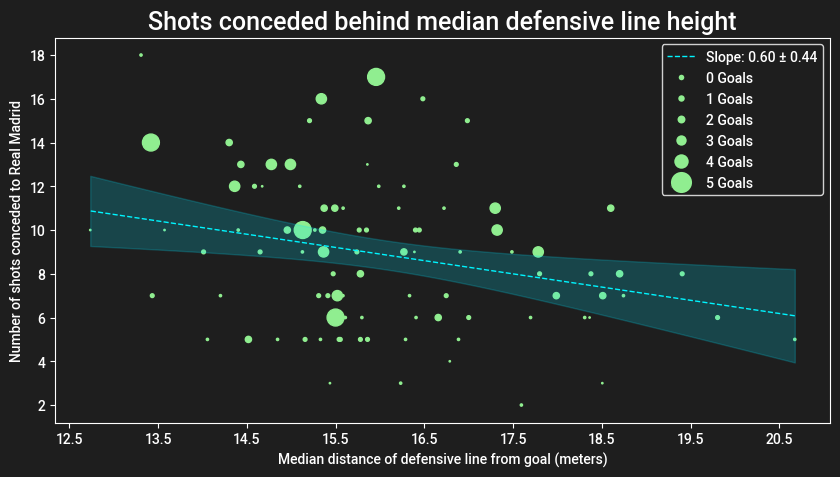

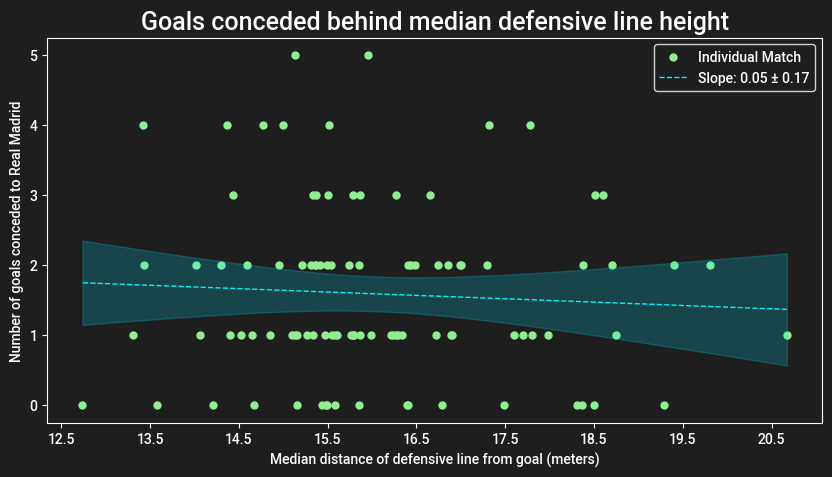

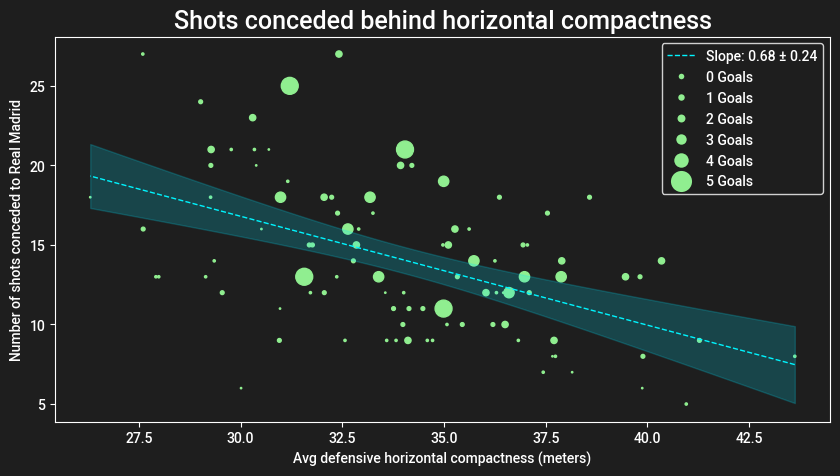

In [10]:
plot_line_height(
  data_df['def_median'].to_numpy(),
  data_df['num_shots_behind_def_line'].to_numpy(),
  title='Shots conceded behind median defensive line height',
  x_label='Median distance of defensive line from goal (meters)',
  y_label='Number of shots conceded to Real Madrid',
  point_sizes=(data_df['rma_goals'].exp()).to_list(),
  # match_ids=data_df['match_id'].to_list(),
)

plot_line_height(
  data_df['def_median'].to_numpy(),
  data_df['num_goals_behind_def_line'].to_numpy(),
  title='Goals conceded behind median defensive line height',
  x_label='Median distance of defensive line from goal (meters)',
  y_label='Number of goals conceded to Real Madrid',
  # match_ids=data_df['match_id'].to_list(),
)

plot_line_height(
  data_df['min_horiz_avg'].to_numpy(),
  data_df['num_shots_behind_horiz'].to_numpy(),
  title='Shots conceded behind horizontal compactness',
  x_label='Avg defensive horizontal compactness (meters)',
  y_label='Number of shots conceded to Real Madrid',
  point_sizes=(data_df['rma_goals'].exp()).to_list(),
  # match_ids=data_df['match_id'].to_list(),
)

## Centroid compactness

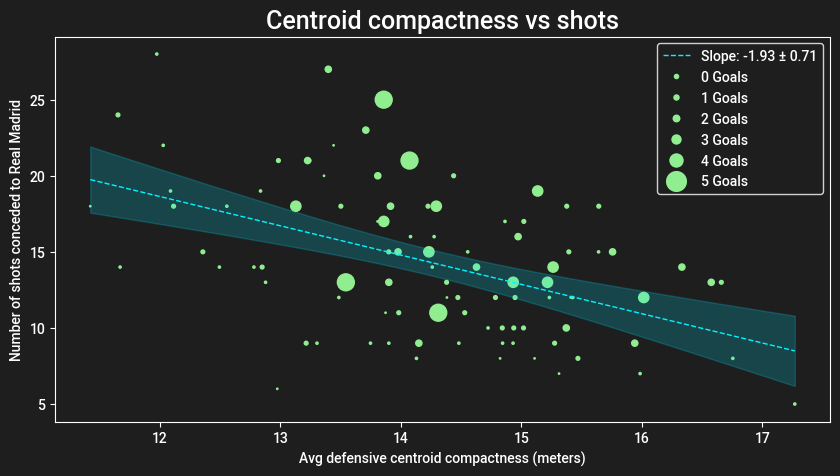

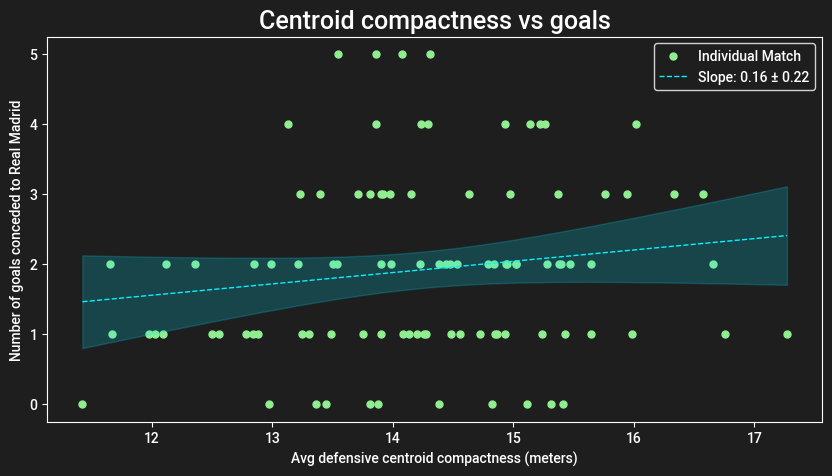

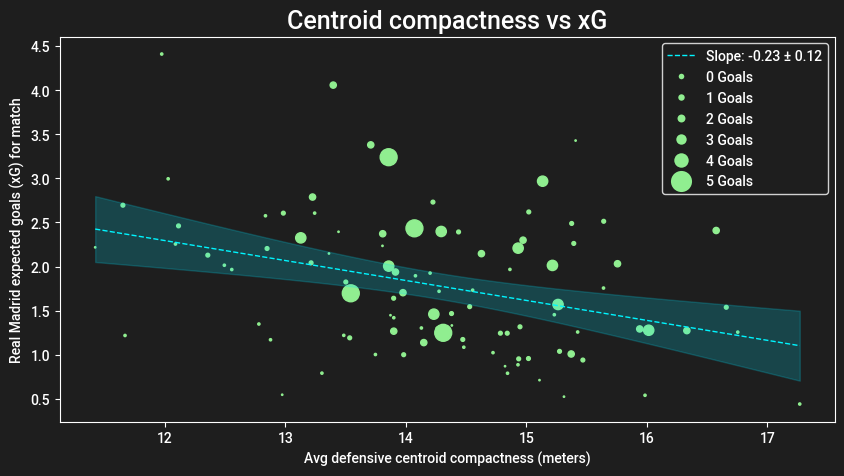

In [11]:
draw_plot(
  data_df['def_compact'].to_numpy(),
  data_df['rma_shots'].to_numpy(),
  title='Centroid compactness vs shots',
  x_label='Avg defensive centroid compactness (meters)',
  y_label='Number of shots conceded to Real Madrid',
  point_sizes=(data_df['rma_goals'].exp()).to_list(),
  # match_ids=data_df['match_id'].to_list(),
)

draw_plot(
  data_df['def_compact'].to_numpy(),
  data_df['rma_goals'].to_numpy(),
  title='Centroid compactness vs goals',
  x_label='Avg defensive centroid compactness (meters)',
  y_label='Number of goals conceded to Real Madrid',
)

draw_plot(
  data_df['def_compact'].to_numpy(),
  data_df['rma_xG'].to_numpy(),
  title='Centroid compactness vs xG',
  x_label='Avg defensive centroid compactness (meters)',
  y_label='Real Madrid expected goals (xG) for match',
  point_sizes=(data_df['rma_goals'].exp()).to_list(),
)


## Horizontal compactness

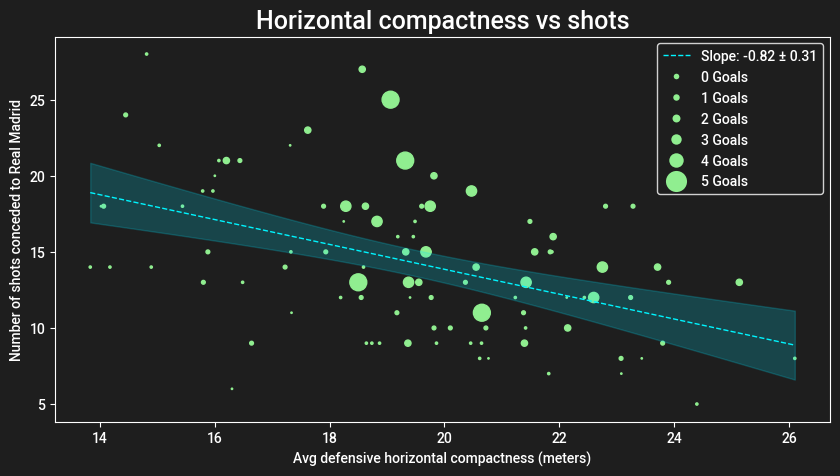

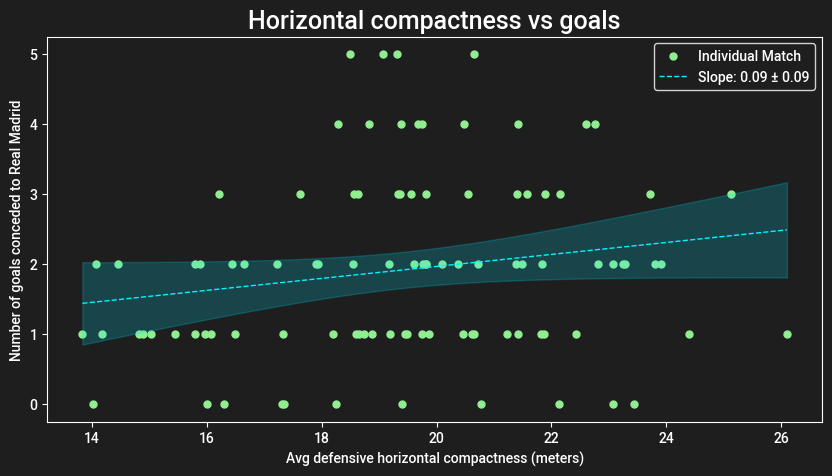

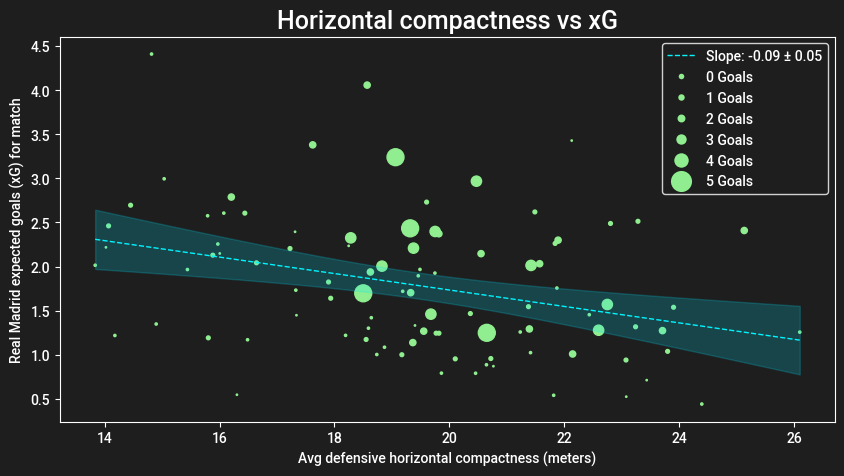

In [12]:
draw_plot(
  data_df['horiz_compact'].to_numpy(),
  data_df['rma_shots'].to_numpy(),
  title='Horizontal compactness vs shots',
  x_label='Avg defensive horizontal compactness (meters)',
  y_label='Number of shots conceded to Real Madrid',
  point_sizes=(data_df['rma_goals'].exp()).to_list(),
)

draw_plot(
  data_df['horiz_compact'].to_numpy(),
  data_df['rma_goals'].to_numpy(),
  title='Horizontal compactness vs goals',
  x_label='Avg defensive horizontal compactness (meters)',
  y_label='Number of goals conceded to Real Madrid',
)

draw_plot(
  data_df['horiz_compact'].to_numpy(),
  data_df['rma_xG'].to_numpy(),
  title='Horizontal compactness vs xG',
  x_label='Avg defensive horizontal compactness (meters)',
  y_label='Real Madrid expected goals (xG) for match',
  point_sizes=(data_df['rma_goals'].exp()).to_list(),
)

# Number of pressures

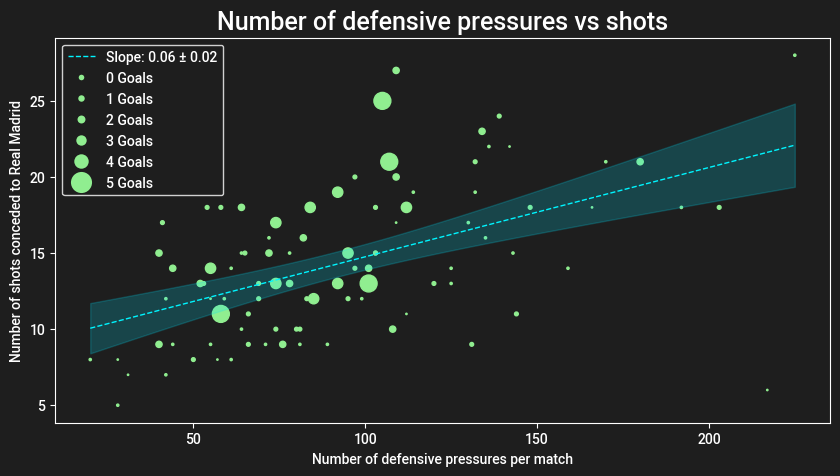

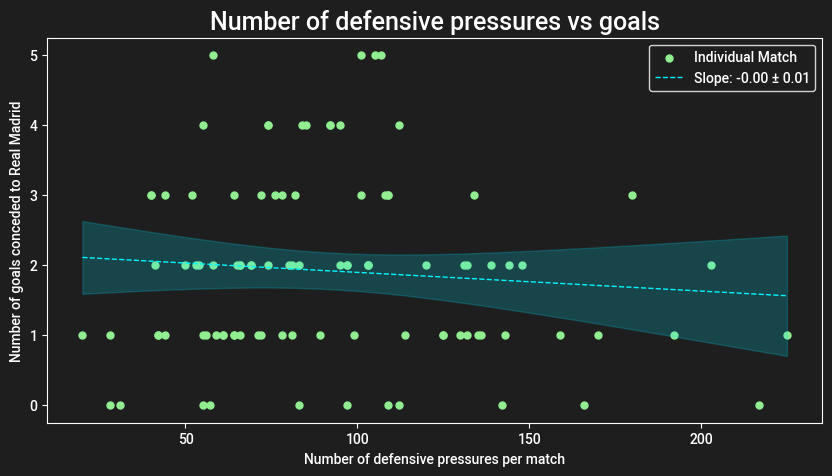

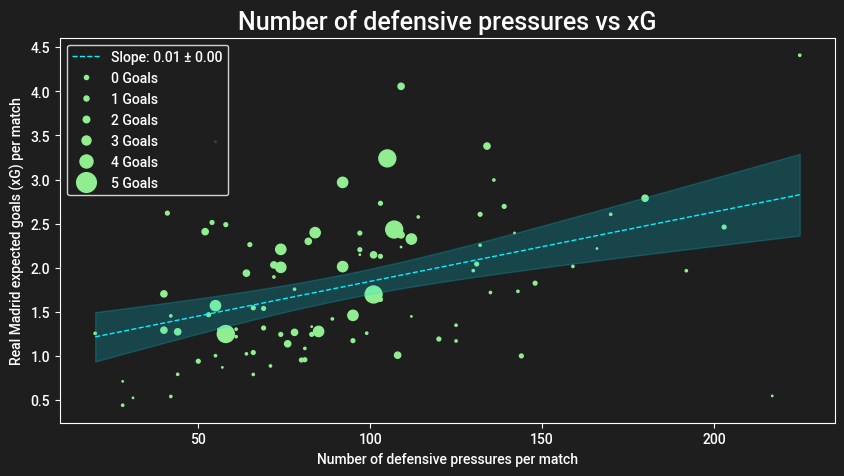

In [13]:
draw_plot(
  data_df['num_pressures'].to_numpy(),
  data_df['rma_shots'].to_numpy(),
  title='Number of defensive pressures vs shots',
  x_label='Number of defensive pressures per match',
  y_label='Number of shots conceded to Real Madrid',
  point_sizes=(data_df['rma_goals'].exp()).to_list(),
  # match_ids=data_df['match_id'].to_list(),
)

draw_plot(
  data_df['num_pressures'].to_numpy(),
  data_df['rma_goals'].to_numpy(),
  title='Number of defensive pressures vs goals',
  x_label='Number of defensive pressures per match',
  y_label='Number of goals conceded to Real Madrid',
)

draw_plot(
  data_df['num_pressures'].to_numpy(),
  data_df['rma_xG'].to_numpy(),
  title='Number of defensive pressures vs xG',
  x_label='Number of defensive pressures per match',
  y_label='Real Madrid expected goals (xG) per match',
  point_sizes=(data_df['rma_goals'].exp()).to_list(),
)

## Heatmap generation code

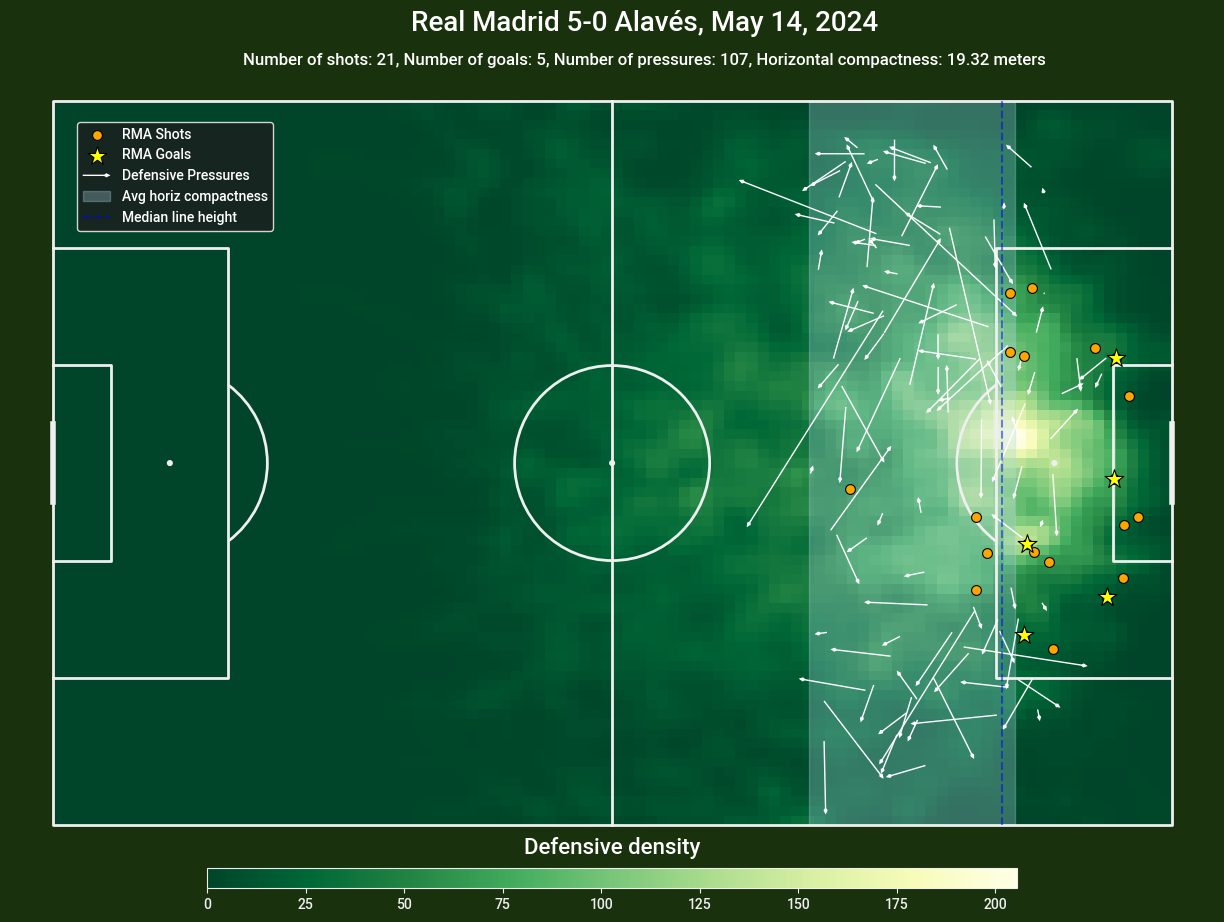

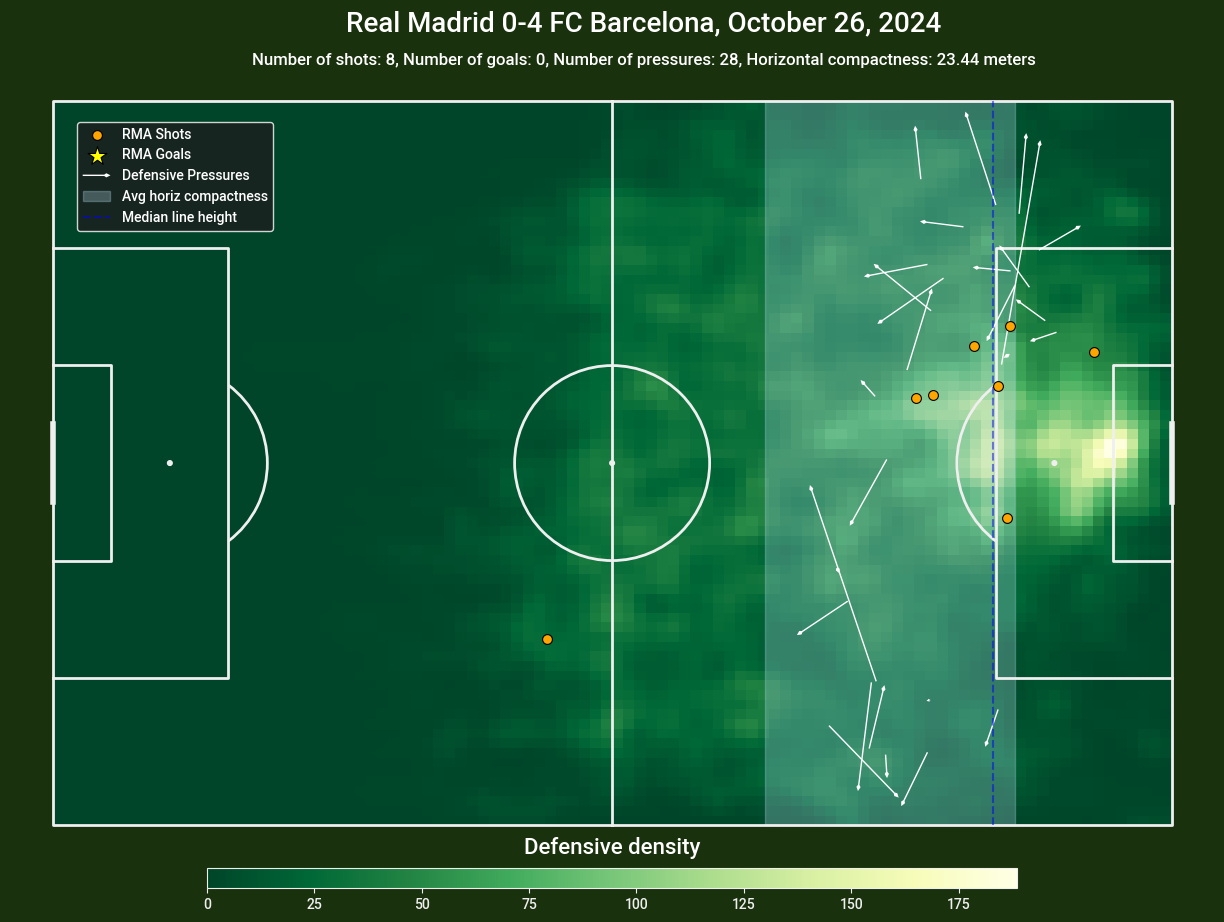

In [14]:
heatmap_matches = [1534700, 1816744] #, 1103734, 2007191, 1492545, 1882238, 2012892]

for match_id in heatmap_matches:
  data = heatmap_data[match_id]
  # pitch = Pitch(pitch_type='skillcorner', pitch_width=68, pitch_length=105, line_zorder=2,
  #               pitch_color='#22312b', line_color='#efefef')
  pitch = Pitch(pitch_type='skillcorner', pitch_width=68, pitch_length=105, line_zorder=2,
                pitch_color='#19310c', line_color='#efefef')
  fig, ax = pitch.draw(figsize=(6.6*2.5, 4.125*2.5))
  # fig.set_facecolor('#22312b')
  fig.set_facecolor('#19310c')

  def_coords_np = data['def_coords'].select('x', 'y').to_numpy()
  bin_statistic = pitch.bin_statistic(def_coords_np[:, 0], def_coords_np[:, 1], statistic='count', bins=(100, 75))
  bin_statistic['statistic'] = gaussian_filter(bin_statistic['statistic'], 1)
  pcm = pitch.heatmap(bin_statistic, ax=ax, cmap='YlGn_r')
  # Add the colorbar and format off-white
  cbar = fig.colorbar(pcm, ax=ax, shrink=0.5, orientation='horizontal', location='bottom', pad=0, aspect=40)
  # cbar.ax.yaxis.set_ticks_position('left')
  cbar.outline.set_edgecolor('#efefef')
  cbar.ax.xaxis.set_tick_params(color='#efefef')
  cbar.ax.yaxis.set_tick_params(color='#efefef')
  ticks = plt.setp(plt.getp(cbar.ax.axes, 'xticklabels'), color='#efefef')
  ticks = plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='#efefef')
  cbar.set_label('Defensive density', color=TEXT_COLOR, size=16)
  cbar.ax.xaxis.set_label_position('top')
  cbar.ax.xaxis.labelpad = 10

  # Defensive coordinate density heatmap
  pitch.scatter(data['rma_shots'][:, 0], data['rma_shots'][:, 1], ax=ax, s=50, c='orange', edgecolors='black', linewidth=0.8, marker='o', label='RMA Shots', zorder=3)
  pitch.scatter(data['rma_goals'][:, 0], data['rma_goals'][:, 1], ax=ax, s=200, c='yellow', edgecolors='black', linewidth=0.8, marker='*', label='RMA Goals', zorder=4)
  pitch.arrows(
    data['pressures']['x_start'] * -1,
    data['pressures']['y_start'] * -1,
    data['pressures']['x_end'] * -1,
    data['pressures']['y_end'] * -1,
    ax=ax, color='white', width=1, headwidth=3, headlength=3, label='Defensive Pressures', zorder=2)
  # ax.axvspan(xmin=35, xmax=45, color='lightblue', alpha=0.3) #, zorder=1)
  ax.fill_betweenx(
    y=[-34, 34],
    x1=data['horiz_compact']['max_horiz'].mean(),
    x2=data['horiz_compact']['min_horiz'].mean(),
    color='lightblue',
    alpha=0.3,
    zorder=1,
    label='Avg horiz compactness')
  # Line height
  ax.plot([data['line_height'], data['line_height']], [-34, 34], color='blue', alpha=0.5, linestyle='--', label='Median line height')

  # Title
  ax.text(
    3, 40,
    f'{data['home_team']} {data['home_team_score']}-{data['away_team_score']} {data['away_team']}, {data['date']}',
    ha='center',
    va='bottom',
    fontsize=20,
    color=TEXT_COLOR,
  )
  # Subtitle
  ax.text(
    3, 38.5,
    f'Number of shots: {len(data["rma_shots"])}, Number of goals: {len(data["rma_goals"])}, Number of pressures: {len(data["pressures"])}, Horizontal compactness: {data["horiz_compact"]["max_horiz"].mean() - data["horiz_compact"]["min_horiz"].mean():.2f} meters',
    ha='center',
    va='top',
    fontsize='12',
    color=TEXT_COLOR,
  )
  plt.legend(loc='upper left', bbox_to_anchor=(0.05, 0.93), facecolor=BG_COLOR, edgecolor=TEXT_COLOR, labelcolor=TEXT_COLOR)
  # Save plots
  # fig.savefig(f'defense_viz_app/pitch_plots/{match_id}.png', dpi=300, bbox_inches='tight')


## Feature importance

Note: the "Defensive line height" feature value range is somewhat misleading. All pitch coordinates have been transformed so that Real Madrid is always attacking left-to-right, and all defensive teams are attacking right-to-left. Therefore the defensive goal is always at the maximum pitch coordinate, e.g. 52.5 meters, and all defense coordinates will decrease from the maximum. So a higher line height is actually smaller horizontal values.

MAE: 4.5188
MSE: 27.9664
RMSE: 5.2883
R-squared: 0.0767


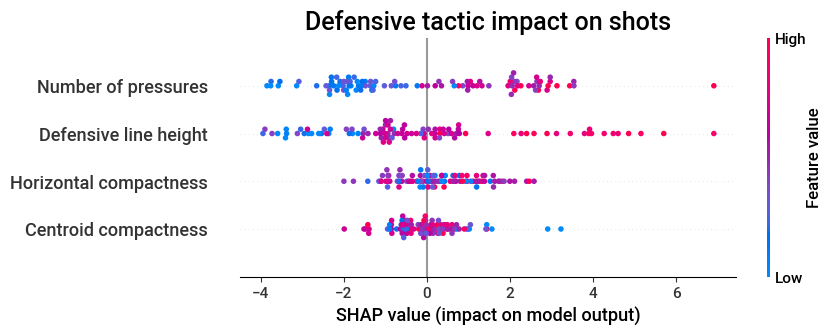

In [15]:
feature_cols = ['def_median', 'def_compact', 'horiz_compact', 'num_pressures']
X = data_df[feature_cols].to_numpy()
y = data_df['rma_shots'].to_numpy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)
model = xgb.XGBRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'MAE: {mae:.4f}')
print(f'MSE: {mse:.4f}')
print(f'RMSE: {np.sqrt(mse):.4f}')
print(f'R-squared: {r2:.4f}')

explainer = shap.TreeExplainer(model, feature_perturbation="tree_path_dependent")
shap_values = explainer(X)
shap_values.feature_names = ['Defensive line height', 'Centroid compactness', 'Horizontal compactness', 'Number of pressures']

plt.title('Defensive tactic impact on shots', fontsize=18)
shap.plots.beeswarm(shap_values)


Note: the R-squared results for these features is negative, so they have no real impact on goal prediction.

MAE: 1.3175
MSE: 2.2549
RMSE: 1.5016
R-squared: -0.5159


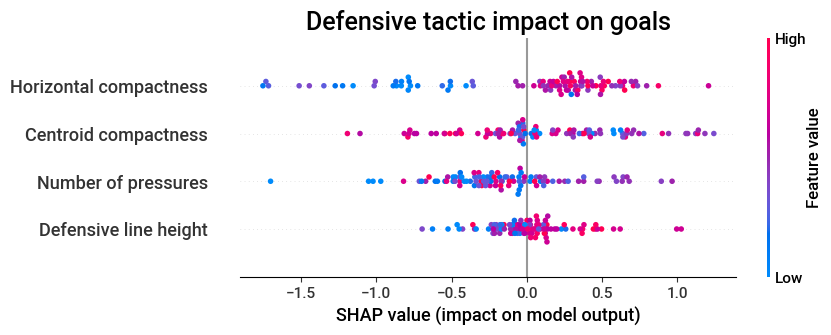

In [27]:
y = data_df['rma_goals'].to_numpy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = xgb.XGBRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'MAE: {mae:.4f}')
print(f'MSE: {mse:.4f}')
print(f'RMSE: {np.sqrt(mse):.4f}')
print(f'R-squared: {r2:.4f}')

explainer = shap.TreeExplainer(model, feature_perturbation="tree_path_dependent")
shap_values = explainer(X)
shap_values.feature_names = ['Defensive line height', 'Centroid compactness', 'Horizontal compactness', 'Number of pressures']

plt.title('Defensive tactic impact on goals', fontsize=18)
shap.plots.beeswarm(shap_values)

In [17]:
# data_df.write_parquet('defense_viz_app/data/data.parquet')